In [1]:
# ==========================================
# CELLULE 1 : IMPORTS ET CONFIGURATION CASCADE
# ==========================================
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import matplotlib.pyplot as plt

# Imports de ton architecture
from src.data import Lungdataset, get_train_transforms, get_val_transforms
from src.models import get_model
from src.training import train_one_epoch, validate, EarlyStopper

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Device actif : {device}")

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    print(f"🔒 Seed fixé à {seed}")

set_seed(42)

BATCH_SIZE = 16
TRAIN_DIR = "data/raw/train"
VAL_DIR = "data/raw/test"
os.makedirs("models", exist_ok=True)

🚀 Device actif : cuda
🔒 Seed fixé à 42


In [3]:
# ==========================================
# CELLULE 2 : DATASETS & LOADERS EXPERTS
# ==========================================

# 1. Chargement des données de base (avec le CLAHE déjà inclus dans tes transforms !)
train_base = Lungdataset(root_dir=TRAIN_DIR, transform=get_train_transforms())
val_base = Lungdataset(root_dir=VAL_DIR, transform=get_val_transforms())

# --- ADAPTATEUR 1 : EXPERT TRIAGE (Normal vs Pneumonie) ---
class TriageDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
        # On garde les labels de base pour le sampler
        self.samples = [(path, 0 if label == 0 else 1) for path, label in base_dataset.samples]

    def __getitem__(self, idx):
        img, label = self.base[idx]
        # Label 0 reste 0 (Normal). Labels 1 et 2 deviennent 1 (Pneumonie)
        binary_label = 0 if label == 0 else 1
        return img, binary_label

    def __len__(self): return len(self.base)

# --- ADAPTATEUR 2 : EXPERT MALADIE (Viral vs Bactérien) ---
class DiseaseDataset(Dataset):
    def __init__(self, base_dataset):
        self.base = base_dataset
        # On ne garde QUE les indices des images malades (label 1 ou 2)
        self.indices = [i for i, (_, label) in enumerate(base_dataset.samples) if label != 0]
        # On recrée une liste samples pour calculer les poids
        self.samples = []
        for i in self.indices:
            path, old_label = base_dataset.samples[i]
            # Viral (1) devient 0, Bactérien (2) devient 1
            new_label = 0 if old_label == 1 else 1
            self.samples.append((path, new_label))

    def __getitem__(self, idx):
        true_idx = self.indices[idx]
        img, old_label = self.base[true_idx]
        binary_label = 0 if old_label == 1 else 1
        return img, binary_label

    def __len__(self): return len(self.indices)

# --- INITIALISATION DES DATASETS ---
train_triage = TriageDataset(train_base)
val_triage = TriageDataset(val_base)

train_disease = DiseaseDataset(train_base)
val_disease = DiseaseDataset(val_base)

print(f"🩺 Expert Triage (Sain/Malade)   : {len(train_triage)} images Train | {len(val_triage)} Val")
print(f"🦠 Expert Maladie (Virus/Bactérie): {len(train_disease)} images Train | {len(val_disease)} Val")

# (Nous créerons les Loaders avec les Samplers juste avant chaque entraînement pour éviter de mélanger les générateurs)

🩺 Expert Triage (Sain/Malade)   : 5216 images Train | 624 Val
🦠 Expert Maladie (Virus/Bactérie): 3875 images Train | 390 Val


In [4]:
# ==========================================
# CELLULE 3 : ENTRAÎNEMENT DE L'EXPERT TRIAGE (Sain vs Malade)
# ==========================================

# 1. On verrouille l'aléatoire
set_seed(42)

# --- A. PRÉPARATION DU SAMPLER ET DATALOADER TRIAGE ---
# On calcule les poids pour nos 2 nouvelles classes (0: Normal, 1: Pneumonie)
triage_labels = [label for _, label in train_triage.samples]
count_0 = triage_labels.count(0)
count_1 = triage_labels.count(1)
print(f"📊 Répartition Triage : Normal={count_0}, Pneumonie={count_1}")

weight_0 = len(triage_labels) / (2 * count_0)
weight_1 = len(triage_labels) / (2 * count_1)
triage_weights = torch.tensor([weight_0, weight_1], dtype=torch.float32).to(device)

sample_weights_triage = [triage_weights[label].item() for label in triage_labels]

g_triage = torch.Generator()
g_triage.manual_seed(42)
sampler_triage = WeightedRandomSampler(
    weights=sample_weights_triage, 
    num_samples=len(sample_weights_triage), 
    replacement=True,
    generator=g_triage
)

def _seed_worker(worker_id):
    worker_seed = torch.initial_seed() % 2**32
    np.random.seed(worker_seed)
    random.seed(worker_seed)

loader_train_triage = DataLoader(train_triage, batch_size=BATCH_SIZE, sampler=sampler_triage, num_workers=4, worker_init_fn=_seed_worker, generator=g_triage)
loader_val_triage = DataLoader(val_triage, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, worker_init_fn=_seed_worker)

# --- B. INITIALISATION DU MODÈLE BINAIRE ---
print("\n⏳ Chargement du modèle Triage (Phase 1 - 2 classes)...")
# ⚠️ Remarque le num_classes=2 !
model_triage = get_model("densenet121", num_classes=2, phase=1).to(device)

criterion_triage = nn.CrossEntropyLoss(weight=triage_weights, label_smoothing=0.05)
optimizer_triage = optim.Adam(filter(lambda p: p.requires_grad, model_triage.parameters()), lr=1e-3)

EPOCHS_TRIAGE = 10
best_acc_triage = 0.0
best_path_triage = "models/expert_triage.pth"

# --- C. BOUCLE D'ENTRAÎNEMENT ---
print(f"\n▶️ Lancement de l'entraînement Expert Triage ({EPOCHS_TRIAGE} époques)...")
for epoch in range(EPOCHS_TRIAGE):
    train_loss = train_one_epoch(
        model_triage, loader_train_triage, criterion_triage, optimizer_triage, device, 
        use_mixup=False, grad_accum_steps=2
    )
    
    val_loss, val_acc = validate(model_triage, loader_val_triage, criterion_triage, device)
    
    print(f"Epoch {epoch+1}/{EPOCHS_TRIAGE} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    if val_acc > best_acc_triage:
        best_acc_triage = val_acc
        torch.save(model_triage.state_dict(), best_path_triage)
        print("   🌟 Nouveau record Expert Triage sauvegardé !")

print(f"\n✅ Terminé ! Rechargement du champion Triage ({best_acc_triage*100:.2f}%)...")
model_triage.load_state_dict(torch.load(best_path_triage, map_location=device, weights_only=True))

🔒 Seed fixé à 42
📊 Répartition Triage : Normal=1341, Pneumonie=3875

⏳ Chargement du modèle Triage (Phase 1 - 2 classes)...

▶️ Lancement de l'entraînement Expert Triage (10 époques)...
Epoch 1/10 | Train Loss: 0.3770 | Val Loss: 0.4318 | Val Acc: 84.62%
   🌟 Nouveau record Expert Triage sauvegardé !
Epoch 2/10 | Train Loss: 0.2520 | Val Loss: 0.4071 | Val Acc: 87.18%
   🌟 Nouveau record Expert Triage sauvegardé !
Epoch 3/10 | Train Loss: 0.2420 | Val Loss: 0.3976 | Val Acc: 87.98%
   🌟 Nouveau record Expert Triage sauvegardé !
Epoch 4/10 | Train Loss: 0.2379 | Val Loss: 0.3974 | Val Acc: 90.71%
   🌟 Nouveau record Expert Triage sauvegardé !
Epoch 5/10 | Train Loss: 0.2452 | Val Loss: 0.3838 | Val Acc: 89.58%
Epoch 6/10 | Train Loss: 0.2345 | Val Loss: 0.3818 | Val Acc: 89.90%
Epoch 7/10 | Train Loss: 0.2343 | Val Loss: 0.3891 | Val Acc: 89.42%
Epoch 8/10 | Train Loss: 0.2246 | Val Loss: 0.3928 | Val Acc: 90.54%
Epoch 9/10 | Train Loss: 0.2254 | Val Loss: 0.3890 | Val Acc: 88.94%
Epoch

<All keys matched successfully>

In [11]:
# ==========================================
# CELLULE 5 : FINE-TUNING DE L'EXPERT MALADIE (Phase 2)
# ==========================================
from torch.optim.lr_scheduler import CosineAnnealingLR
# 1. On re-fixe l'aléatoire
set_seed(42)

print(" Chargement du modèle Maladie (Phase 2 - Dégel partiel)...")
model_disease_p2 = get_model("densenet121", num_classes=2, phase=2).to(device)

# 2. On charge le socle de la Phase 1 (le record à 87.18%)
model_disease_p2.load_state_dict(torch.load(best_path_disease, map_location=device, weights_only=True))
print(" Poids de la Phase 1 chargés avec succès !")

# 3. Séparation des paramètres (Discriminative Learning Rate)
head_params = []
backbone_params = []
for name, param in model_disease_p2.named_parameters():
    if not param.requires_grad:
        continue
    if "classifier" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

# 4. Optimiseur chirurgical (petits pas)
optimizer_disease_p2 = optim.Adam([
    {"params": backbone_params, "lr": 1e-5}, # Très faible pour le corps
    {"params": head_params, "lr": 1e-4}      # Moyen pour la tête
], weight_decay=1e-4)

EPOCHS_DISEASE_P2 = 30
scheduler_disease = CosineAnnealingLR(optimizer_disease_p2, T_max=EPOCHS_DISEASE_P2, eta_min=1e-7)
early_stopper_disease = EarlyStopper(patience=8, min_delta=0.0)

best_acc_disease_p2 = 0.0
best_path_disease_p2 = "models/expert_disease_final.pth"

print(f"\n Lancement du Fine-Tuning Expert Maladie ({EPOCHS_DISEASE_P2} époques)...")

for epoch in range(EPOCHS_DISEASE_P2):
    current_lr = optimizer_disease_p2.param_groups[0]["lr"]
    
    # Entraînement sans Mixup (pour profiter à 100% de la netteté du CLAHE)
    train_loss = train_one_epoch(
        model_disease_p2, loader_train_disease, criterion_disease, optimizer_disease_p2, device, 
        use_mixup=False, grad_accum_steps=2
    )
    
    scheduler_disease.step()
    
    val_loss, val_acc = validate(model_disease_p2, loader_val_disease, criterion_disease, device)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS_DISEASE_P2} (LR: {current_lr:.2e}) | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    if val_acc > best_acc_disease_p2:
        best_acc_disease_p2 = val_acc
        torch.save(model_disease_p2.state_dict(), best_path_disease_p2)
        print("   ### Nouveau record absolu Expert Maladie sauvegardé ! ###")

    early_stopper_disease(val_loss)
    if early_stopper_disease.early_stop:
        print(f"\n Early Stopping déclenché à l'époque {epoch+1} !")
        break

print(f"\n Terminé ! Rechargement du champion final Maladie ({best_acc_disease_p2*100:.2f}%)...")
model_disease_p2.load_state_dict(torch.load(best_path_disease_p2, map_location=device, weights_only=True))
print(" L'Expert Maladie est prêt !")

🔒 Seed fixé à 42
 Chargement du modèle Maladie (Phase 2 - Dégel partiel)...
 Poids de la Phase 1 chargés avec succès !

 Lancement du Fine-Tuning Expert Maladie (30 époques)...
Epoch 01/30 (LR: 1.00e-05) | Train Loss: 0.5552 | Val Loss: 0.4303 | Val Acc: 81.03%
   ### Nouveau record absolu Expert Maladie sauvegardé ! ###
Epoch 02/30 (LR: 9.97e-06) | Train Loss: 0.5510 | Val Loss: 0.4623 | Val Acc: 73.33%
Epoch 03/30 (LR: 9.89e-06) | Train Loss: 0.5429 | Val Loss: 0.4347 | Val Acc: 77.95%
Epoch 04/30 (LR: 9.76e-06) | Train Loss: 0.5206 | Val Loss: 0.4064 | Val Acc: 84.36%
   ### Nouveau record absolu Expert Maladie sauvegardé ! ###
Epoch 05/30 (LR: 9.57e-06) | Train Loss: 0.5174 | Val Loss: 0.3935 | Val Acc: 87.18%
   ### Nouveau record absolu Expert Maladie sauvegardé ! ###
Epoch 06/30 (LR: 9.34e-06) | Train Loss: 0.5001 | Val Loss: 0.3992 | Val Acc: 83.08%
Epoch 07/30 (LR: 9.05e-06) | Train Loss: 0.5008 | Val Loss: 0.3905 | Val Acc: 85.38%
Epoch 08/30 (LR: 8.73e-06) | Train Loss: 0.49

In [13]:
# ==========================================
# CELLULE 5.1 : FINE-TUNING EXTRÊME (CORRIGÉE)
# ==========================================
from torch.optim.lr_scheduler import CosineAnnealingLR

# 1. On re-fixe l'aléatoire
set_seed(42)

print("⏳ Chargement du modèle Maladie...")
model_disease_p3 = get_model("densenet121", num_classes=2, phase=2).to(device)

# 2. On charge ton champion de la Phase 2 (le record à 87.69%)
model_disease_p3.load_state_dict(torch.load("models/expert_disease_final.pth", map_location=device, weights_only=True))
print("✅ Poids de la Phase 2 chargés avec succès !")

# 🔓 LE CORRECTIF EST ICI : Dégel manuel de 100% des paramètres
print("🔓 Dégel total du modèle (Force Unfreeze)...")
for param in model_disease_p3.parameters():
    param.requires_grad = True

# Vérification : Tu DOIS voir 100% !
trainable = sum(p.numel() for p in model_disease_p3.parameters() if p.requires_grad)
total = sum(p.numel() for p in model_disease_p3.parameters())
print(f"🧠 Params entraînables (Phase 3) : {trainable:,} / {total:,} ({(trainable/total)*100:.2f}%)")

# 3. Optimiseur ultra-chirurgical 
head_params = []
backbone_params = []
for name, param in model_disease_p3.named_parameters():
    if "classifier" in name:
        head_params.append(param)
    else:
        backbone_params.append(param)

optimizer_disease_p3 = optim.Adam([
    {"params": backbone_params, "lr": 5e-6}, # LR microscopique pour le corps
    {"params": head_params, "lr": 5e-5}      # LR très faible pour la tête
], weight_decay=1e-4)

# ... (Le reste de la cellule avec la boucle for reste identique, tu peux garder tes 20 époques) ...

EPOCHS_DISEASE_P3 = 20
scheduler_disease_p3 = CosineAnnealingLR(optimizer_disease_p3, T_max=EPOCHS_DISEASE_P3, eta_min=1e-7)
early_stopper_disease_p3 = EarlyStopper(patience=5, min_delta=0.0)

best_acc_disease_p3 = 0.0
best_path_disease_p3 = "models/expert_disease_phase3.pth"

print(f"\n▶️ Lancement de l'ultime Fine-Tuning ({EPOCHS_DISEASE_P3} époques)...")

for epoch in range(EPOCHS_DISEASE_P3):
    current_lr = optimizer_disease_p3.param_groups[0]["lr"]
    
    train_loss = train_one_epoch(
        model_disease_p3, loader_train_disease, criterion_disease, optimizer_disease_p3, device, 
        use_mixup=False, grad_accum_steps=2
    )
    
    scheduler_disease_p3.step()
    val_loss, val_acc = validate(model_disease_p3, loader_val_disease, criterion_disease, device)
    
    print(f"Epoch {epoch+1:02d}/{EPOCHS_DISEASE_P3} (LR: {current_lr:.2e}) | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc*100:.2f}%")
    
    if val_acc > best_acc_disease_p3:
        best_acc_disease_p3 = val_acc
        torch.save(model_disease_p3.state_dict(), best_path_disease_p3)
        print("   🏆 Nouveau record ULTIME Expert Maladie sauvegardé !")

    early_stopper_disease_p3(val_loss)
    if early_stopper_disease_p3.early_stop:
        print(f"\n⏹️ Early Stopping déclenché à l'époque {epoch+1} !")
        break

print(f"\n✅ Terminé ! Rechargement du champion final Phase 3 ({best_acc_disease_p3*100:.2f}%)...")
model_disease_p3.load_state_dict(torch.load(best_path_disease_p3, map_location=device, weights_only=True))

🔒 Seed fixé à 42
⏳ Chargement du modèle Maladie...
✅ Poids de la Phase 2 chargés avec succès !
🔓 Dégel total du modèle (Force Unfreeze)...
🧠 Params entraînables (Phase 3) : 6,955,906 / 6,955,906 (100.00%)

▶️ Lancement de l'ultime Fine-Tuning (20 époques)...
Epoch 01/20 (LR: 5.00e-06) | Train Loss: 0.4735 | Val Loss: 0.3885 | Val Acc: 83.33%
   🏆 Nouveau record ULTIME Expert Maladie sauvegardé !
Epoch 02/20 (LR: 4.97e-06) | Train Loss: 0.4680 | Val Loss: 0.3721 | Val Acc: 86.67%
   🏆 Nouveau record ULTIME Expert Maladie sauvegardé !
Epoch 03/20 (LR: 4.88e-06) | Train Loss: 0.4413 | Val Loss: 0.4146 | Val Acc: 76.67%
Epoch 04/20 (LR: 4.73e-06) | Train Loss: 0.4546 | Val Loss: 0.3787 | Val Acc: 84.10%
Epoch 05/20 (LR: 4.53e-06) | Train Loss: 0.4258 | Val Loss: 0.4272 | Val Acc: 73.59%
Epoch 06/20 (LR: 4.28e-06) | Train Loss: 0.4382 | Val Loss: 0.3533 | Val Acc: 91.03%
   🏆 Nouveau record ULTIME Expert Maladie sauvegardé !
Epoch 07/20 (LR: 3.99e-06) | Train Loss: 0.4376 | Val Loss: 0.3687

<All keys matched successfully>

📊 1. BILAN CLINIQUE : EXPERT TRIAGE (Sain vs Malade)


╔══════════════════════════════════════╗
║      BILAN D'ÉVALUATION CLINIQUE     ║
╚══════════════════════════════════════╝

Précision globale : 90.71%

Matrice de confusion :
                    Sain      Malade
        Sain         201          33
      Malade          25         365

Rapport détaillé :
              precision    recall  f1-score   support

        Sain     0.8894    0.8590    0.8739       234
      Malade     0.9171    0.9359    0.9264       390

    accuracy                         0.9071       624
   macro avg     0.9032    0.8974    0.9002       624
weighted avg     0.9067    0.9071    0.9067       624

  📊 Heatmap sauvegardée → results/confusion_expert_triage.png

Matrice de confusion générée :


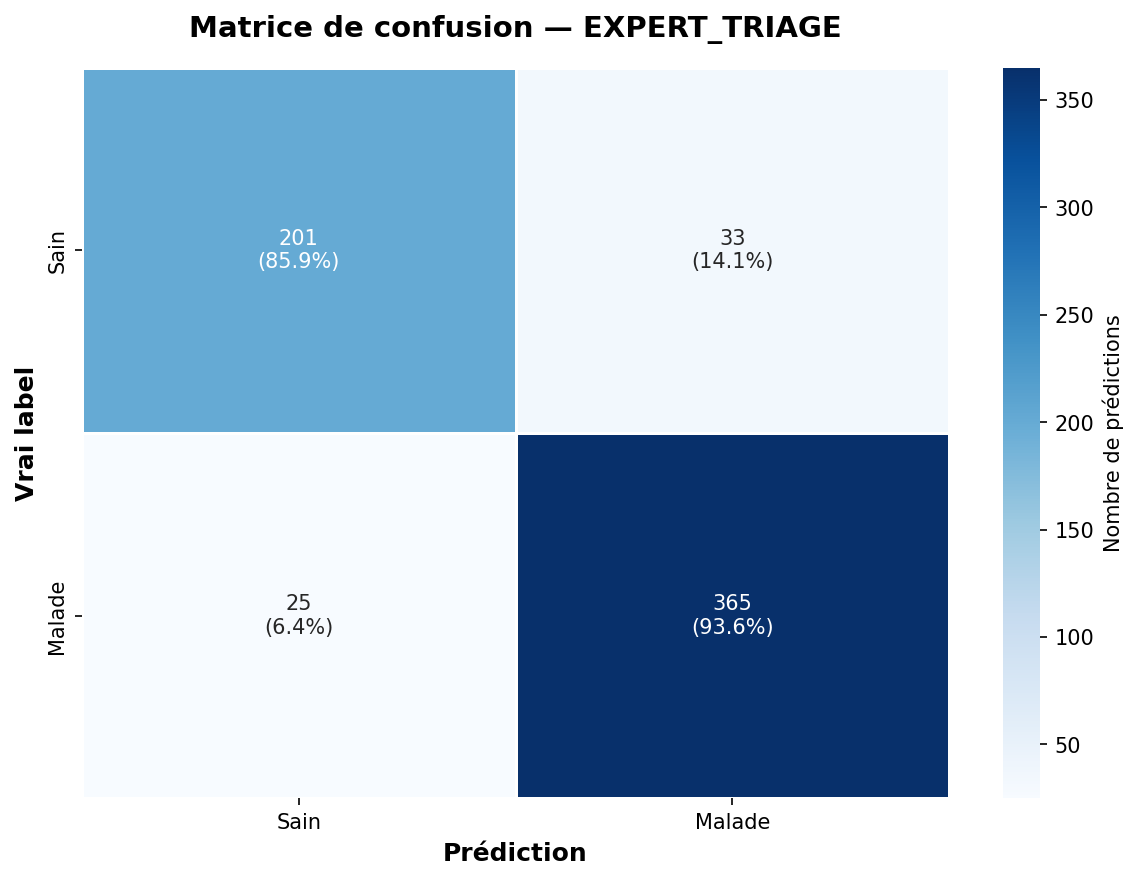


🧐 2. MUR DES ERREURS : EXPERT TRIAGE (A-t-il triché ?)


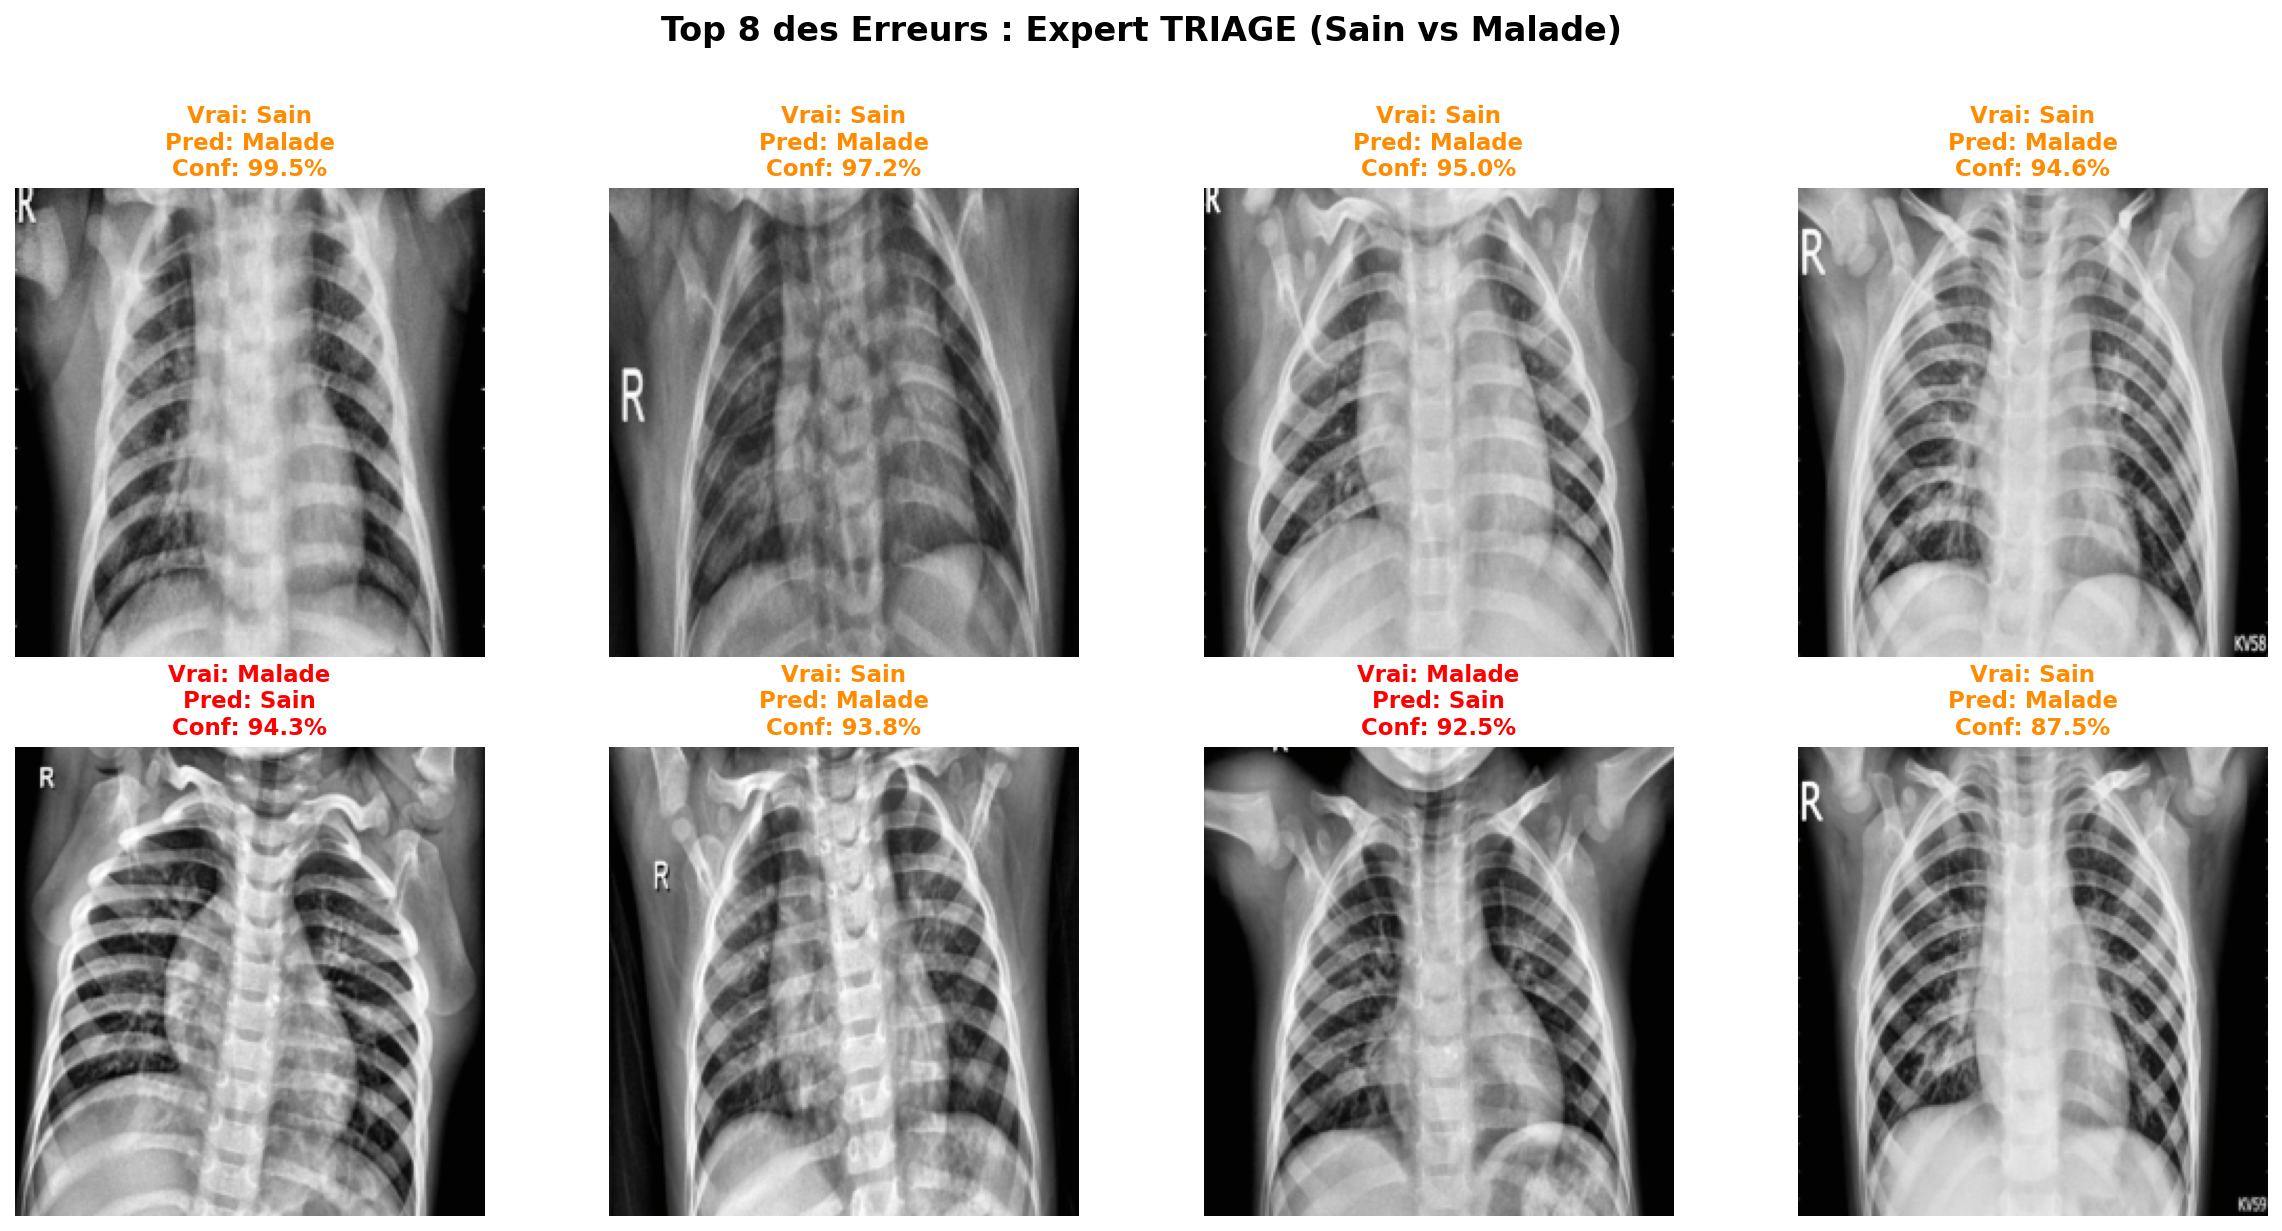

In [9]:
# ==========================================
# CELLULE 6 : ÉVALUATION DE L'EXPERT TRIAGE
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from src.training.evaluate import evaluate_model

print("📊 1. BILAN CLINIQUE : EXPERT TRIAGE (Sain vs Malade)\n")
# Définition des classes binaires pour cet expert
CLASSES_TRIAGE = ["Sain", "Malade"]

# Évaluation standard
results_triage = evaluate_model(
    model_triage, 
    loader_val_triage, 
    device, 
    classes=CLASSES_TRIAGE, 
    model_name="expert_triage"
)

# Affichage de la matrice
print("\nMatrice de confusion générée :")
display(Image(filename=results_triage['heatmap']))

print("\n" + "="*60)
print("🧐 2. MUR DES ERREURS : EXPERT TRIAGE (A-t-il triché ?)")
print("="*60)

model_triage.eval()
misclassified_triage = []

with torch.no_grad():
    for images, labels in loader_val_triage:
        images, labels = images.to(device), labels.to(device)
        outputs = model_triage(images)
        probas = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probas, 1)
        
        for i in range(len(labels)):
            vrai_label = labels[i].item()
            pred_label = preds[i].item()
            
            if vrai_label != pred_label:
                img_cpu = images[i].cpu().numpy().transpose((1, 2, 0))
                # Dénormalisation
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_cpu = std * img_cpu + mean
                img_cpu = np.clip(img_cpu, 0, 1)
                
                misclassified_triage.append({
                    "image": img_cpu,
                    "vrai": vrai_label,
                    "predit": pred_label,
                    "confiance": confidences[i].item() * 100
                })

misclassified_triage = sorted(misclassified_triage, key=lambda x: x["confiance"], reverse=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Top 8 des Erreurs : Expert TRIAGE (Sain vs Malade)", fontsize=16, fontweight='bold', y=1.02)

for idx, ax in enumerate(axes.flatten()):
    if idx < len(misclassified_triage):
        erreur = misclassified_triage[idx]
        ax.imshow(erreur["image"])
        titre = f"Vrai: {CLASSES_TRIAGE[erreur['vrai']]}\nPred: {CLASSES_TRIAGE[erreur['predit']]}\nConf: {erreur['confiance']:.1f}%"
        # Rouge = Faux Négatif grave (Malade classé Sain), Orange = Faux Positif (Sain classé Malade)
        color = "red" if erreur['vrai'] == 1 else "darkorange"
        ax.set_title(titre, color=color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
erreurs_path_triage = "results/mur_erreurs_triage.png"
plt.savefig(erreurs_path_triage, dpi=150, bbox_inches="tight")
plt.close(fig)

display(Image(filename=erreurs_path_triage))

📊 1. BILAN CLINIQUE : EXPERT MALADIE ULTIME (Viral vs Bactérien)


╔══════════════════════════════════════╗
║      BILAN D'ÉVALUATION CLINIQUE     ║
╚══════════════════════════════════════╝

Précision globale : 91.03%

Matrice de confusion :
                   Viral   Bactérien
       Viral         127          21
   Bactérien          14         228

Rapport détaillé :
              precision    recall  f1-score   support

       Viral     0.9007    0.8581    0.8789       148
   Bactérien     0.9157    0.9421    0.9287       242

    accuracy                         0.9103       390
   macro avg     0.9082    0.9001    0.9038       390
weighted avg     0.9100    0.9103    0.9098       390

  📊 Heatmap sauvegardée → results/confusion_expert_disease_phase3.png

Matrice de confusion générée :


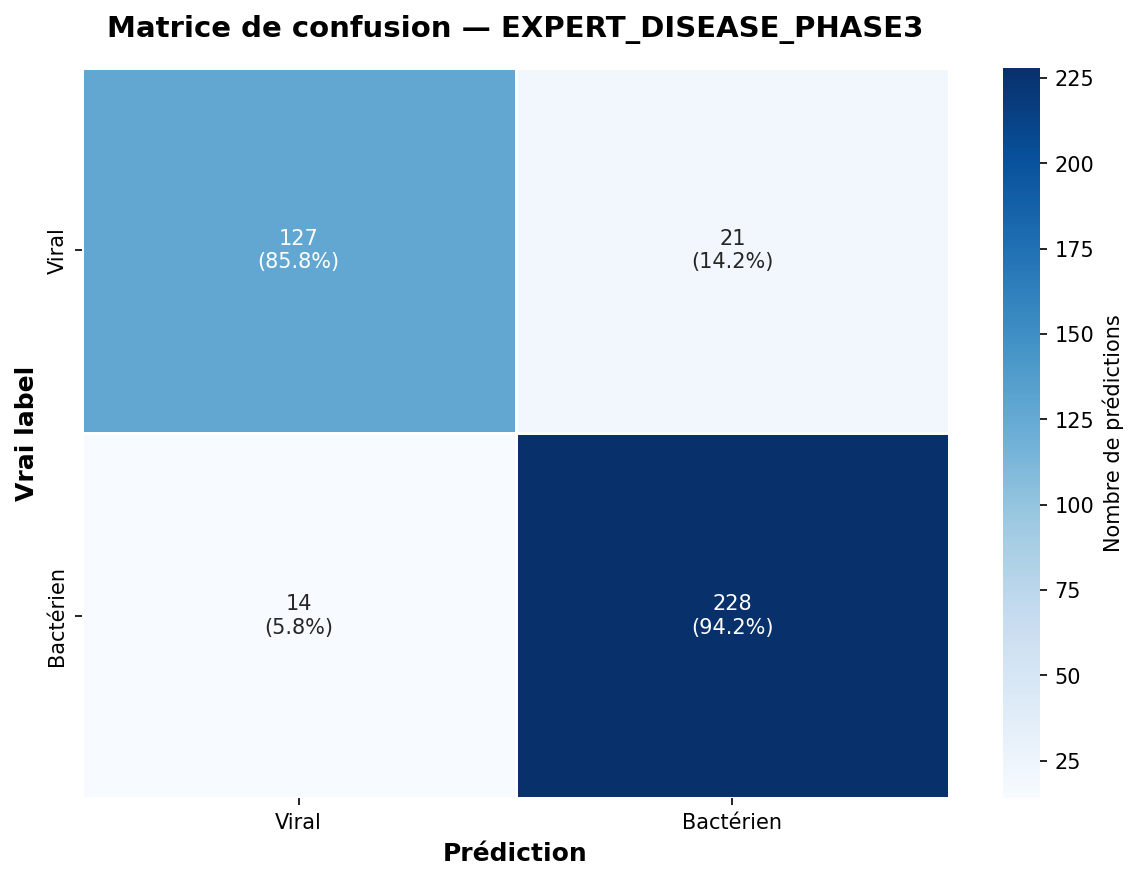


🧐 2. MUR DES ERREURS : EXPERT MALADIE (Phase 3)


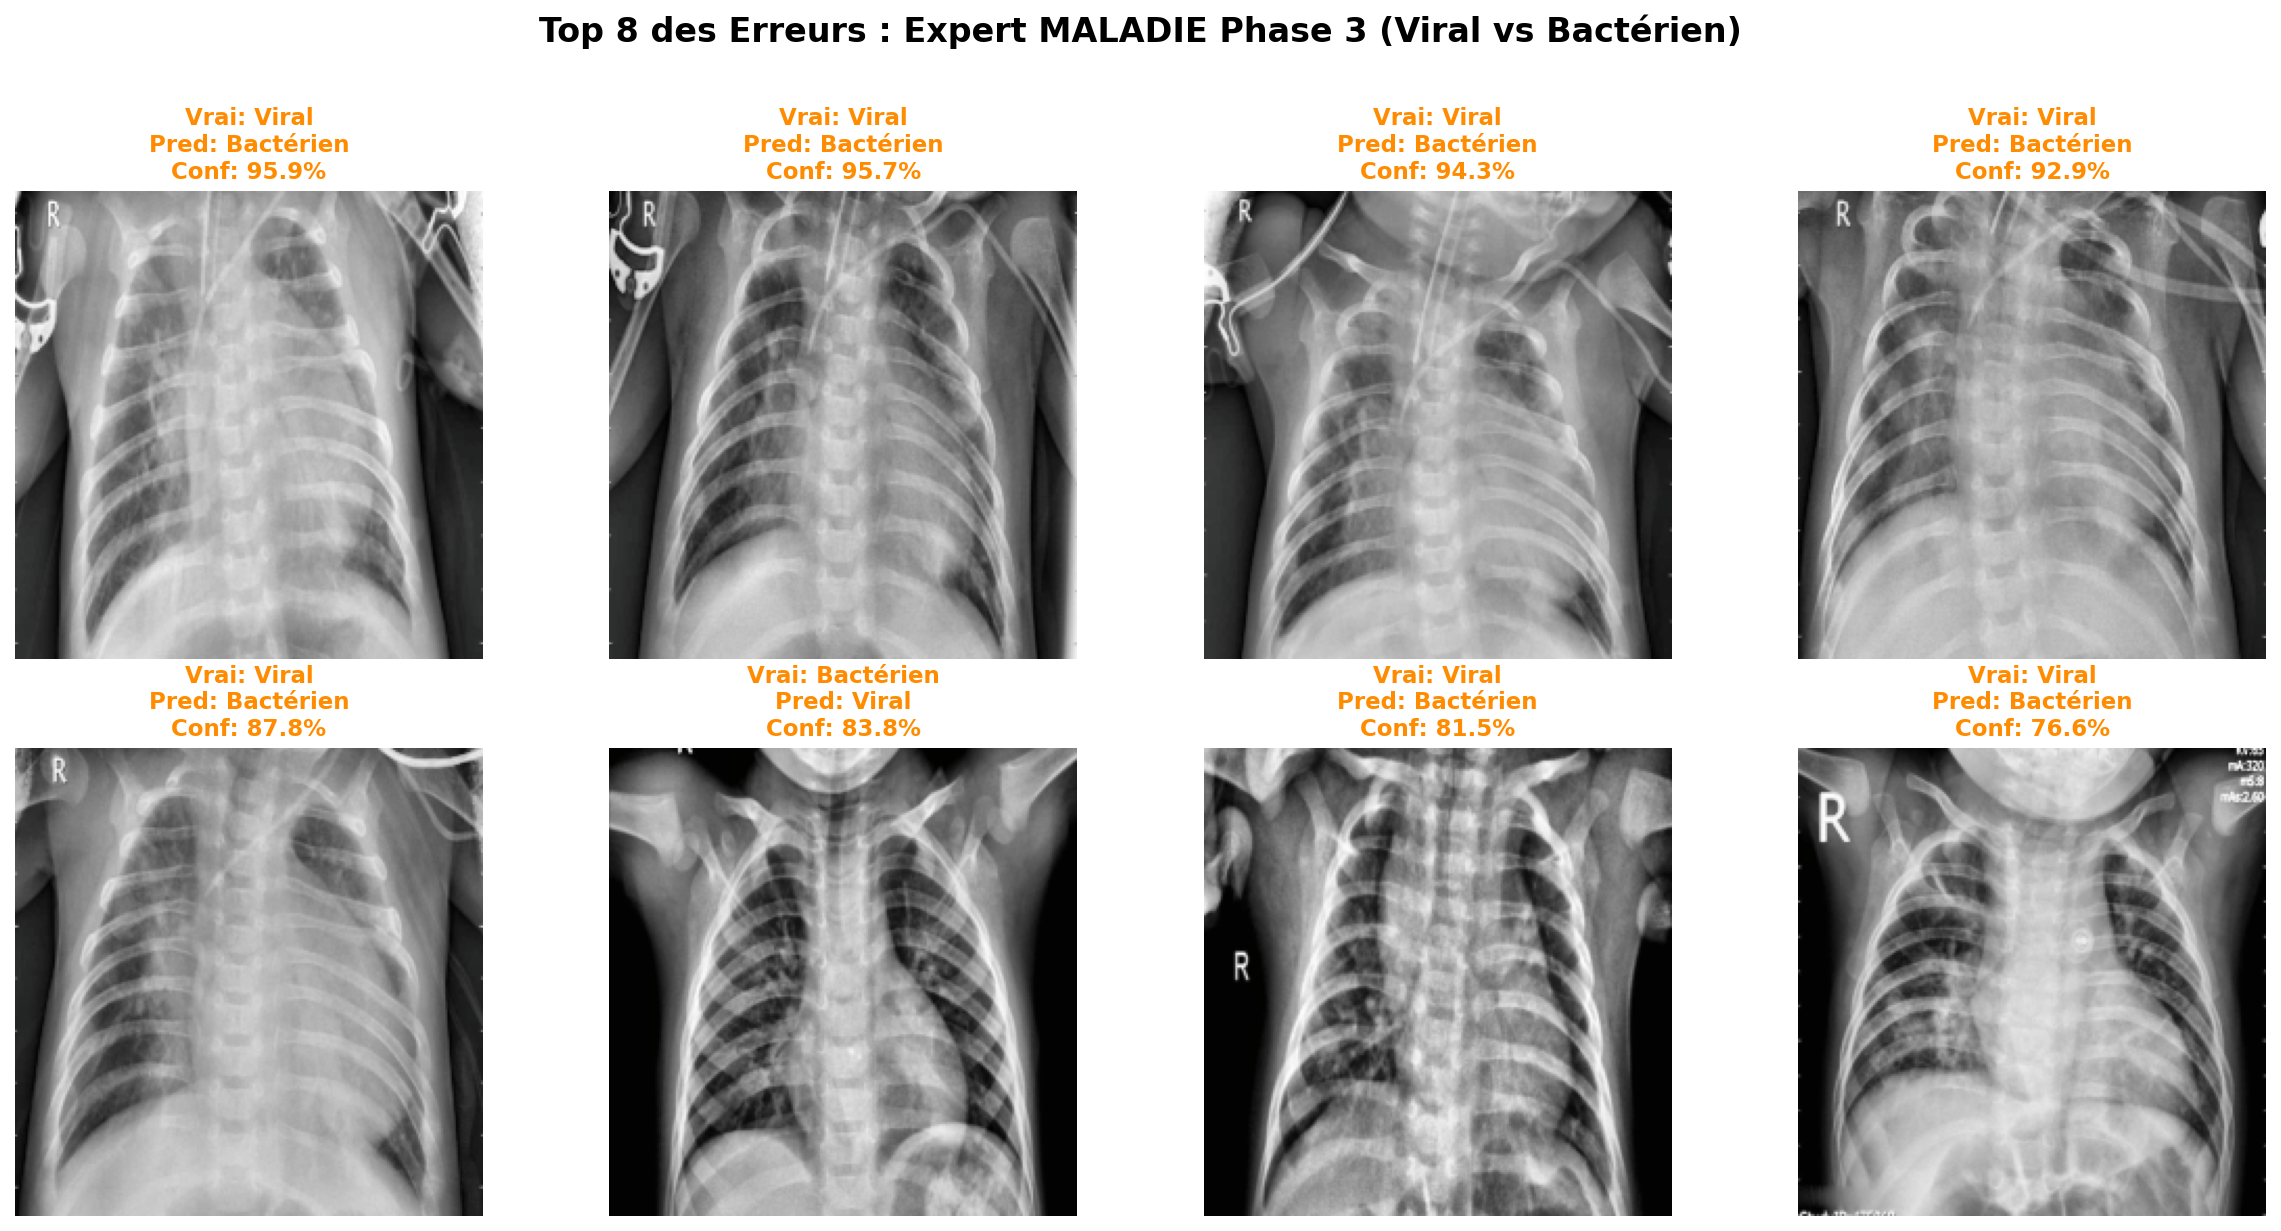

In [14]:
# ==========================================
# CELLULE 7 : ÉVALUATION ULTIME DE L'EXPERT MALADIE (Phase 3)
# ==========================================
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from IPython.display import Image, display
from src.training.evaluate import evaluate_model

print("📊 1. BILAN CLINIQUE : EXPERT MALADIE ULTIME (Viral vs Bactérien)\n")
CLASSES_DISEASE = ["Viral", "Bactérien"]

# Évaluation du NOUVEAU champion : model_disease_p3
results_disease = evaluate_model(
    model_disease_p3, 
    loader_val_disease, 
    device, 
    classes=CLASSES_DISEASE, 
    model_name="expert_disease_phase3"
)

print("\nMatrice de confusion générée :")
display(Image(filename=results_disease['heatmap']))

print("\n" + "="*60)
print("🧐 2. MUR DES ERREURS : EXPERT MALADIE (Phase 3)")
print("="*60)

model_disease_p3.eval()
misclassified_disease = []

with torch.no_grad():
    for images, labels in loader_val_disease:
        images, labels = images.to(device), labels.to(device)
        outputs = model_disease_p3(images)
        probas = F.softmax(outputs, dim=1)
        confidences, preds = torch.max(probas, 1)
        
        for i in range(len(labels)):
            vrai_label = labels[i].item()
            pred_label = preds[i].item()
            
            if vrai_label != pred_label:
                img_cpu = images[i].cpu().numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img_cpu = std * img_cpu + mean
                img_cpu = np.clip(img_cpu, 0, 1)
                
                misclassified_disease.append({
                    "image": img_cpu,
                    "vrai": vrai_label,
                    "predit": pred_label,
                    "confiance": confidences[i].item() * 100
                })

# On trie pour voir les pires erreurs (haute confiance)
misclassified_disease = sorted(misclassified_disease, key=lambda x: x["confiance"], reverse=True)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Top 8 des Erreurs : Expert MALADIE Phase 3 (Viral vs Bactérien)", fontsize=16, fontweight='bold', y=1.02)

for idx, ax in enumerate(axes.flatten()):
    if idx < len(misclassified_disease):
        erreur = misclassified_disease[idx]
        ax.imshow(erreur["image"])
        titre = f"Vrai: {CLASSES_DISEASE[erreur['vrai']]}\nPred: {CLASSES_DISEASE[erreur['predit']]}\nConf: {erreur['confiance']:.1f}%"
        color = "darkorange"
        ax.set_title(titre, color=color, fontsize=11, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
erreurs_path_disease = "results/mur_erreurs_disease_p3.png"
plt.savefig(erreurs_path_disease, dpi=150, bbox_inches="tight")
plt.close(fig)

display(Image(filename=erreurs_path_disease))